In [1]:
!pip -q install qiskit qiskit-aer pylatexenc matplotlib

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.8/9.8 MB 82.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 72.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 137.5/137.5 kB 6.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 59.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.5/54.5 kB 3.2 MB/s eta 0:00:00


In [2]:
from qiskit import QuantumCircuit, transpile
from qiskit.quantum_info import Statevector
from qiskit.visualization import plot_histogram
from qiskit_aer import AerSimulator
import matplotlib.pyplot as plt
import numpy as np

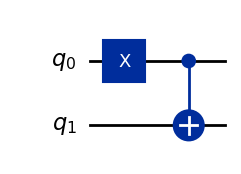

Final Statevector:
Statevector([0.+0.j, 0.+0.j, 0.+0.j, 1.+0.j],
            dims=(2, 2))


In [3]:
from qiskit import QuantumCircuit
from qiskit.quantum_info import Statevector

qc = QuantumCircuit(2)

# Control qubit = |1>
qc.x(0)

# CNOT Gate
qc.cx(0, 1)

display(qc.draw("mpl"))

state = Statevector.from_instruction(qc)

print("Final Statevector:")
print(state)


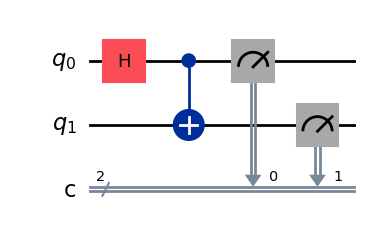

{'00': 531, '11': 493}


In [4]:
from qiskit import QuantumCircuit, transpile
from qiskit_aer import AerSimulator
from qiskit.visualization import plot_histogram
import matplotlib.pyplot as plt

qc = QuantumCircuit(2,2)

qc.h(0)
qc.cx(0,1)

qc.measure([0,1],[0,1])

display(qc.draw("mpl"))

simulator = AerSimulator()

compiled = transpile(qc, simulator)

job = simulator.run(compiled, shots=1024)

result = job.result()

counts = result.get_counts()

print(counts)

plot_histogram(counts)
plt.show()

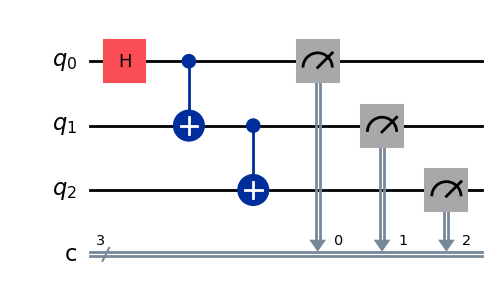

{'111': 490, '000': 534}


In [5]:
from qiskit import QuantumCircuit, transpile
from qiskit_aer import AerSimulator
from qiskit.visualization import plot_histogram
import matplotlib.pyplot as plt

qc = QuantumCircuit(3,3)

qc.h(0)

qc.cx(0,1)

qc.cx(1,2)

qc.measure([0,1,2],[0,1,2])

display(qc.draw("mpl"))

simulator = AerSimulator()

compiled = transpile(qc, simulator)

job = simulator.run(compiled, shots=1024)

result = job.result()

counts = result.get_counts()

print(counts)

plot_histogram(counts)
plt.show()

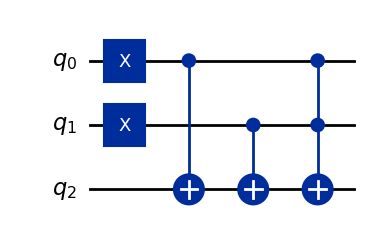

Statevector([0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j,
             1.+0.j],
            dims=(2, 2, 2))


In [6]:
from qiskit import QuantumCircuit
from qiskit.quantum_info import Statevector

qc = QuantumCircuit(3)

# Example Inputs:
# A = 1
# B = 1
# Carry-In = 0

qc.x(0)
qc.x(1)

# Sum
qc.cx(0,2)
qc.cx(1,2)

# Carry
qc.ccx(0,1,2)

display(qc.draw("mpl"))

state = Statevector.from_instruction(qc)

print(state)

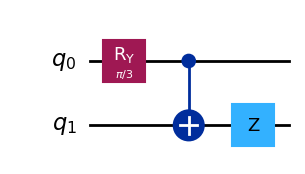

Statevector:
Statevector([ 0.8660254+0.j,  0.       +0.j,  0.       +0.j,
             -0.5      +0.j],
            dims=(2, 2))

Probability Distribution:
|00> : 0.7500
|01> : 0.0000
|10> : 0.0000
|11> : 0.2500


In [7]:
from qiskit import QuantumCircuit
from qiskit.quantum_info import Statevector

qc = QuantumCircuit(2)

# Create a non-standard entangled state

qc.ry(np.pi/3,0)

qc.cx(0,1)

qc.z(1)

display(qc.draw("mpl"))

state = Statevector.from_instruction(qc)

print("Statevector:")

print(state)

print("\nProbability Distribution:")

probabilities = np.abs(state.data)**2

for i,p in enumerate(probabilities):
    print(f"|{i:02b}> : {p:.4f}")